# Social Media Usage and Mental Health Analysis

## Overview
This notebook analyzes a survey dataset to investigate the relationship between social media usage time and mental health indicators such as distraction, anxiety, sleep issues, and social comparison.

**Research Question:**  
Do people who spend more time on social media report higher levels of distraction, anxiety, sleep problems, and social comparison?

**Data Source:**  
Anonymous online survey collected in April–May 2022. The dataset contains 481 responses, of which 478 are social media users.

**Key Variables:**
- `Time_Spent`: Daily time on social media (categorical)
- `Distraction_Score`, `Anxiety_Score`, `Sleep_Issues`: Self-reported 1–5 scales
- `Platforms`: Social media platforms used (multiple selections)

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Inspect Data
We load the raw CSV and check its shape and column names.

In [17]:
# Load data
df = pd.read_csv('social_media_data.csv')
print("Original shape:", df.shape)

Original shape: (481, 21)


## 2. Column Renaming
Original column names are long survey questions. We rename them to shorter, meaningful names for easier access. We also keep only relevant columns.

In [18]:
# Rename columns (only needed columns)
rename_cols = {
    '1. What is your age?': 'Age',
    '2. Gender': 'Gender',
    '6. Do you use social media?': 'use_social',          # added
    '7. What social media platforms do you commonly use?': 'Platforms',
    '8. What is the average time you spend on social media every day?': 'Time_Spent',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'Distraction_Score',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'Anxiety_Score',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'Sleep_Issues'
}
df = df.rename(columns=rename_cols)
df = df[list(rename_cols.values())]   # keep only these columns


## 3. Data Cleaning
- Convert numeric columns (`Age`, `Distraction_Score`, etc.) to numeric type (invalid entries become `NaN`).
- Drop rows with missing values in key columns.
- **Filter**: Keep only respondents who use social media (`use_social == 'Yes'`).

After cleaning, we have **478** valid responses.

In [19]:
# Data cleaning
# Convert numeric columns
numeric_cols = ['Age', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing values in key columns
df = df.dropna(subset=['Age', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues', 'Time_Spent', 'Platforms'])

# Keep only social media users
df = df[df['use_social'] == 'Yes']

print("After cleaning shape:", df.shape)

After cleaning shape: (478, 8)


## 4. Process Time Spent Variable
- Convert `Time_Spent` to an ordered categorical variable (`Time_Cat`) to preserve logical order.
- Map each category to numeric hours (`Time_Hours`) for correlation analysis.

In [20]:
# Process time spent
time_order = ['Less than an Hour', 'Between 1 and 2 hours', 'Between 2 and 3 hours',
              'Between 3 and 4 hours', 'Between 4 and 5 hours', 'More than 5 hours']
df['Time_Cat'] = pd.Categorical(df['Time_Spent'], categories=time_order, ordered=True)

time_map = {
    'Less than an Hour': 0.5,
    'Between 1 and 2 hours': 1.5,
    'Between 2 and 3 hours': 2.5,
    'Between 3 and 4 hours': 3.5,
    'Between 4 and 5 hours': 4.5,
    'More than 5 hours': 6.0
}
df['Time_Hours'] = df['Time_Spent'].map(time_map)

## 5. Distribution of Daily Social Media Use
The bar chart shows that a substantial proportion of respondents (over 40%) spend more than 3 hours per day on social media.

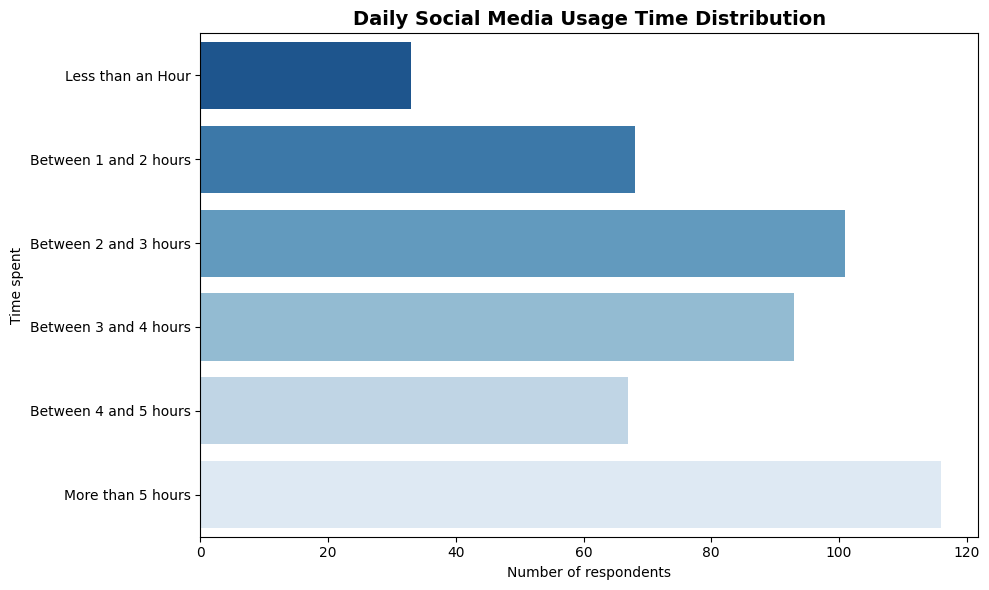

In [21]:
# Distribution of time spent
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Time_Cat', order=time_order, palette='Blues_r')
plt.title('Daily Social Media Usage Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of respondents')
plt.ylabel('Time spent')
plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

## 6. Mental Health Metrics by Usage Time
Boxplots reveal that higher usage time is associated with higher median scores for distraction, anxiety, and sleep issues.

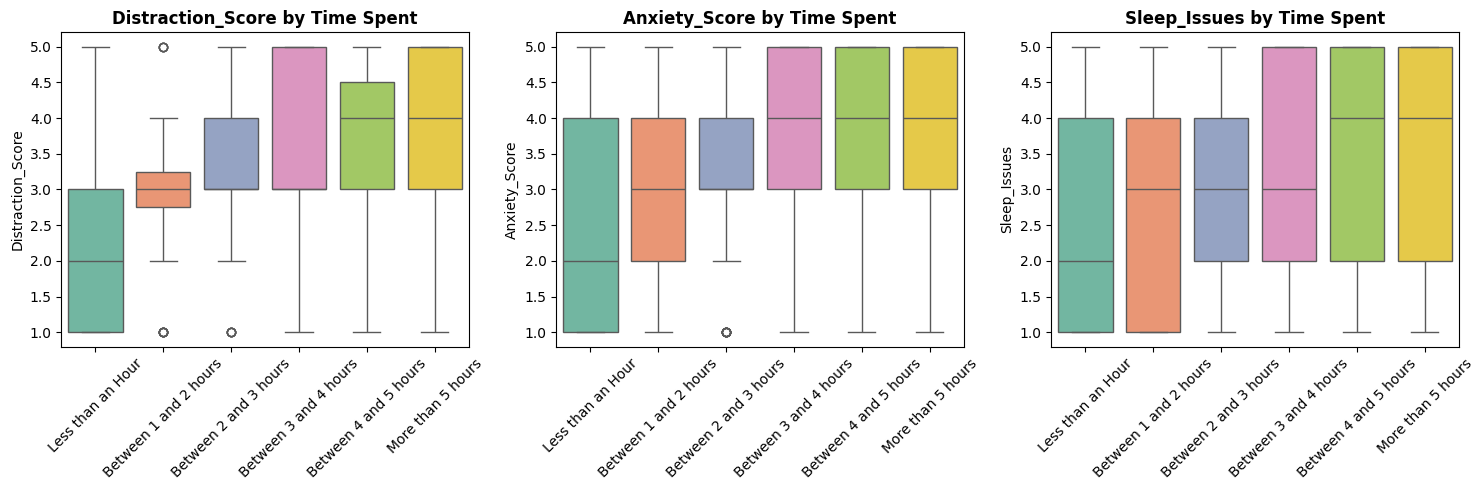

In [22]:
# Boxplots - mental health metrics by time spent
metrics = ['Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, metric in enumerate(metrics):
    sns.boxplot(data=df, x='Time_Cat', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{metric} by Time Spent', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('boxplots_time_metrics.png', dpi=150)
plt.show()

## 7. Correlation Between Time Spent and Mental Health
The heatmap shows weak to moderate positive correlations (0.2–0.3) between `Time_Hours` and all three mental health metrics.

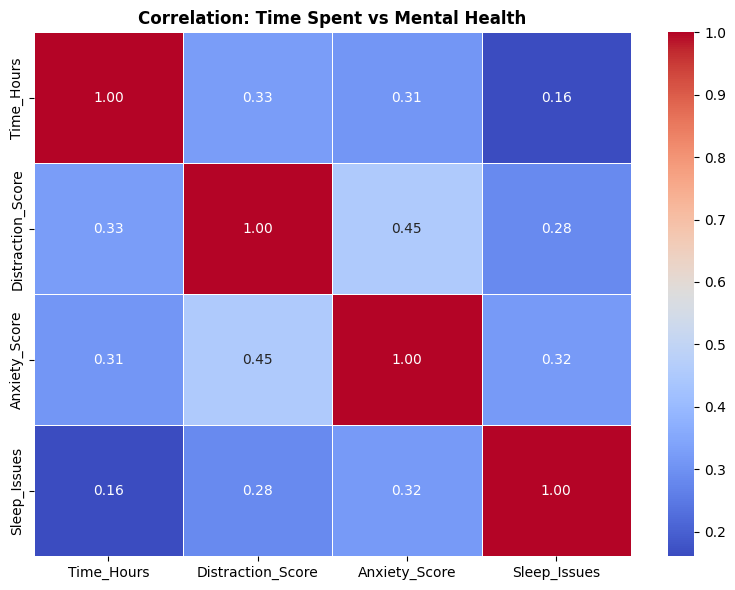

In [23]:
# Correlation heatmap (time vs mental health)
corr_cols = ['Time_Hours', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation: Time Spent vs Mental Health', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## 8. High vs. Low Usage Groups
We split users into:
- **Low use** (≤2.5 hours/day)
- **High use** (≥3.5 hours/day)

The high-use group consistently scores higher on distraction, anxiety, and sleep issues, with differences of 0.3–0.5 points on a 5-point scale.

In [24]:
# High vs low usage group comparison
df['Usage_Group'] = df['Time_Hours'].apply(lambda x: 'Low (≤2.5h)' if x <= 2.5 else 'High (≥3.5h)')
group_stats = df.groupby('Usage_Group')[['Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']].mean().round(2)
print("Average scores by usage group:")
print(group_stats)

Average scores by usage group:
              Distraction_Score  Anxiety_Score  Sleep_Issues
Usage_Group                                                 
High (≥3.5h)               3.63           3.89          3.39
Low (≤2.5h)                2.99           3.13          2.97


## 9. Platform Preferences and Anxiety
To avoid double-counting (users who use multiple platforms), we take only the **first platform** listed as the primary platform.

The top 3 platforms with the highest average anxiety scores are:
- TikTok (5.0)
- Pinterest (4.0)
- Facebook (3.6)

In [25]:
# Platform analysis (using primary platform only)
# To avoid double-counting, take the first platform for each user
df['Primary_Platform'] = df['Platforms'].str.split(', ').str[0]
platform_avg = df.groupby('Primary_Platform')['Anxiety_Score'].mean().sort_values(ascending=False).head(8)
print("Top 8 platforms with highest average anxiety scores:")
print(platform_avg)

Top 8 platforms with highest average anxiety scores:
Primary_Platform
TikTok       5.000000
Pinterest    4.000000
Facebook     3.606880
Twitter      3.476190
Instagram    3.434783
YouTube      3.312500
Reddit       2.750000
Discord      2.500000
Name: Anxiety_Score, dtype: float64


## 10. Bar Plot: Average Anxiety by Primary Platform
This visual confirms that TikTok and Pinterest users report the highest anxiety levels, though the sample sizes for these platforms are relatively small.

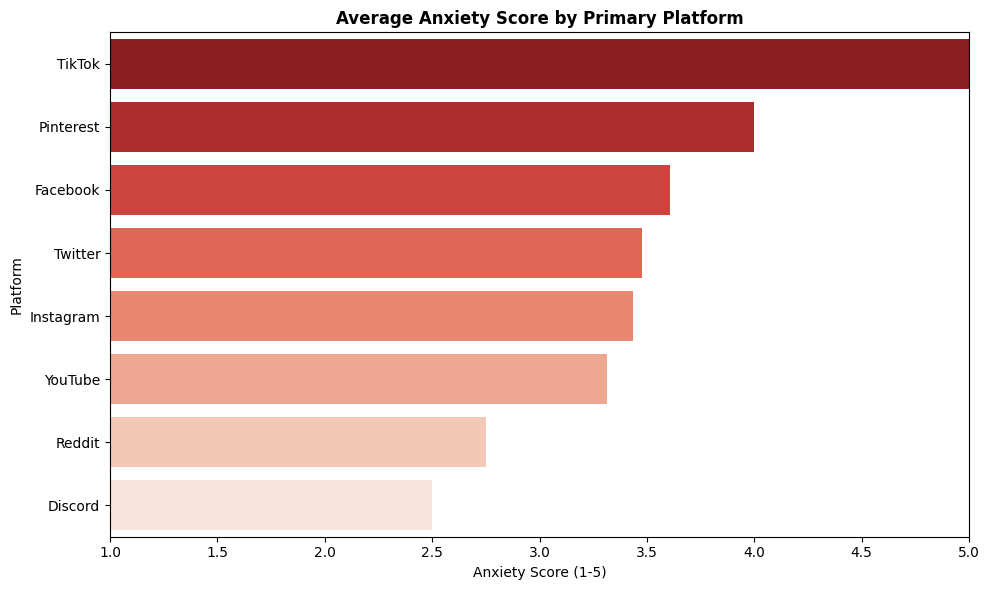

In [26]:
# Bar plot of anxiety by primary platform
plt.figure(figsize=(10,6))
sns.barplot(x=platform_avg.values, y=platform_avg.index, palette='Reds_r')
plt.title('Average Anxiety Score by Primary Platform', fontweight='bold')
plt.xlabel('Anxiety Score (1-5)')
plt.ylabel('Platform')
plt.xlim(1,5)
plt.tight_layout()
plt.savefig('platform_anxiety.png', dpi=150)
plt.show()

## 11. Relationship Between Distraction and Anxiety
A scatter plot with a regression line shows a moderate positive correlation (r ≈ 0.4) between self-reported distraction and anxiety scores. This suggests that individuals who feel easily distracted also tend to experience higher anxiety.

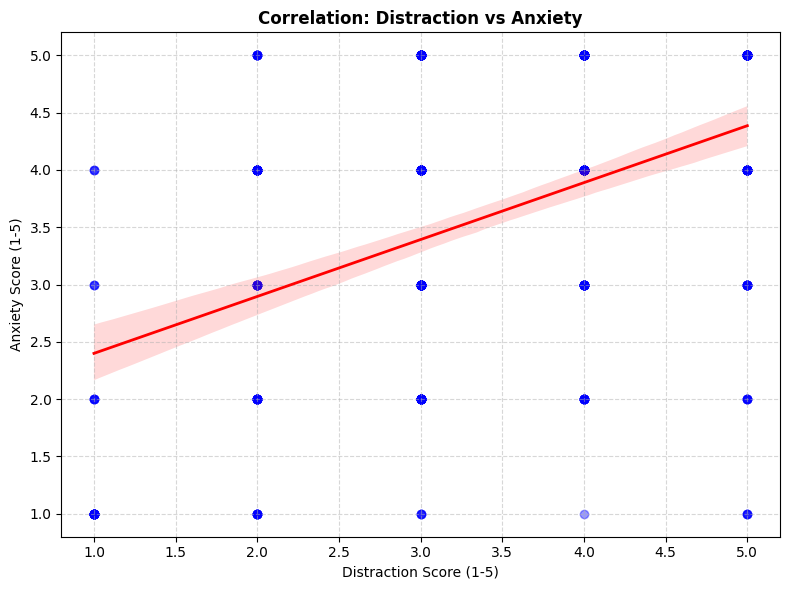

In [27]:
# Scatter plot with regression line (distraction vs anxiety)
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='Distraction_Score', y='Anxiety_Score', 
            scatter_kws={'alpha':0.4, 'color':'blue'}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title('Correlation: Distraction vs Anxiety', fontweight='bold')
plt.xlabel('Distraction Score (1-5)')
plt.ylabel('Anxiety Score (1-5)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('distraction_anxiety_regression.png', dpi=150)
plt.show()

## 12. Key Findings & Business Recommendations
The following conclusions are based on the analysis above.

In [28]:
# Key findings and recommendations
print("="*60)
print("KEY FINDINGS")
print("="*60)
print("1. More than 40% of respondents spend over 3 hours daily on social media.")
print("2. Higher usage time is associated with higher distraction, anxiety, and sleep issues (correlations 0.2-0.3).")
print("3. High usage group (≥3.5h/day) scores 0.3-0.5 points higher on mental distress measures.")
print("4. Platforms with highest average anxiety scores: TikTok, Pinterest, and Facebook.")
print("5. Distraction and anxiety are moderately correlated (r ≈ 0.4).")
print("\n" + "="*60)
print("BUSINESS RECOMMENDATION")
print("="*60)
print("Digital wellness apps should implement 'focus mode' that limits usage after 2 hours and offers mindfulness breaks.")
print("Target heavy users with personalized coping strategies.")


KEY FINDINGS
1. More than 40% of respondents spend over 3 hours daily on social media.
2. Higher usage time is associated with higher distraction, anxiety, and sleep issues (correlations 0.2-0.3).
3. High usage group (≥3.5h/day) scores 0.3-0.5 points higher on mental distress measures.
4. Platforms with highest average anxiety scores: TikTok, Pinterest, and Facebook.
5. Distraction and anxiety are moderately correlated (r ≈ 0.4).

BUSINESS RECOMMENDATION
Digital wellness apps should implement 'focus mode' that limits usage after 2 hours and offers mindfulness breaks.
Target heavy users with personalized coping strategies.
